In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 16               # 본문 크기
mpl.rcParams['axes.labelsize'] = 18         # 축 라벨
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['mathtext.fontset'] = 'cm'      # LaTeX 수식은 Computer Modern 유지
mpl.rcParams['axes.linewidth'] = 1.0   

In [3]:
from Simul2 import get_RQ_OA
from scipy.signal import find_peaks

In [4]:
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]

Q_init = 0.6
alpha = 0.3
beta = 0.3

In [5]:
alpha = 0.3
beta = 0.5
Q1 = 1
shift =1
eta1 = 0.4
Q2 = 0.6
eta2 = 0.5
R1s, R2s, Q1s, Q2s,t = get_RQ_OA(Q1, Q2, alpha, beta, eta1, eta2, omega=0.0, shift=shift, t_end=5000, dt=0.01)

In [113]:
np.sqrt(np.sin(alpha))

0.5436177026747193

In [114]:
O = (1-2*eta1)**2*np.sqrt(np.sin(alpha)**2-beta**4)
P = np.pi/O
print(P)

498.4049510273661


$$Det(J) = 4(1-2\eta_{\sigma'})^4(\sin^2\alpha-\mu^4) > 0$$

$\lambda = \pm i \sqrt{Det(J)}$
$$\Omega = \sqrt{Det(J)} = 2(1-2\eta_{\sigma'})^2 \sqrt{\sin^2\alpha - \mu^4}$$
$$T = \frac{2\pi}{\Omega} = \frac{\pi}{(1-2\eta_{\sigma'})^2 \sqrt{\sin^2\alpha - \mu^4}}$$

$$C_0 = \frac{\sin\alpha - \mu^2 Q_\sigma \sin(2\phi+\alpha)}{1 - Q_\sigma^2}$$

$$Q_{max} = \frac{\mu^2 + \sqrt{\mu^4 - 4C_0(\sin\alpha - C_0)}}{2C_0}$$
$$Q_{min} = \left|\frac{-\mu^2 + \sqrt{\mu^4 - 4C_0(\sin\alpha - C_0)}}{2C_0}\right|$$

In [115]:
mu = beta
C_0 = (np.sin(alpha) - beta**2 * Q2 * np.sin(-2*shift + alpha))/(1-Q2**2)
Q_max = (mu**2 + np.sqrt(mu**4 - 4*C_0*(np.sin(alpha) - C_0)))/(2*C_0)
Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(alpha) - C_0)))/(2*C_0)
print(Q_max, Q_min)
DQ = Q_max - Q_min

0.9589861062729436 0.5988446926109051


In [116]:
shift = np.linspace(0,np.pi,1000)
C_0s = (np.sin(alpha) - beta**2 * Q2 * np.sin(-2*shift + alpha))/(1-Q2**2)
DQs = mu**2 / C_0s
Q_maxs = (mu**2 + np.sqrt(mu**4 - 4*C_0s*(np.sin(alpha) - C_0s)))/(2*C_0s)
Q_mins = abs(mu**2 - np.sqrt(mu**4 - 4*C_0s*(np.sin(alpha) - C_0s)))/(2*C_0s)

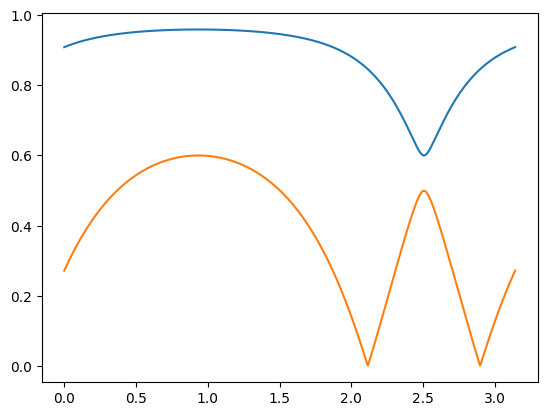

In [117]:
plt.plot(shift,Q_maxs)
plt.plot(shift,Q_mins)

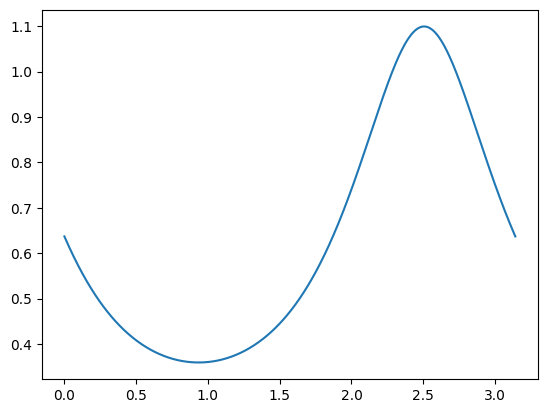

In [118]:
plt.plot(shift,DQs)

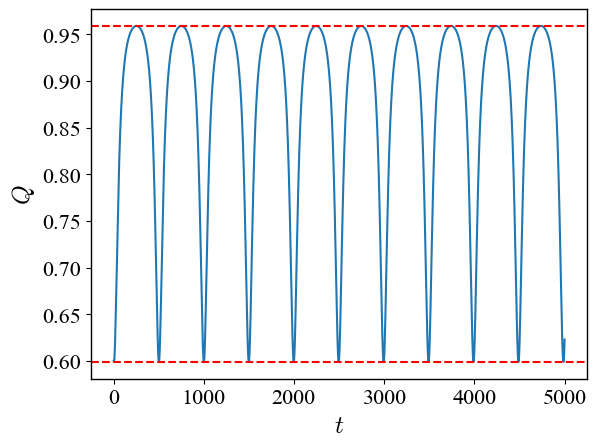

In [122]:
plt.plot(t,Q2s)
plt.axhline(Q_max, color='r', linestyle='--')
plt.axhline(Q_min, color='r', linestyle='--')
plt.xlabel(r'$t$')
plt.ylabel(r'$Q$')
# plt.legend()
plt.show()

In [68]:
DQ = mu**2 / C_0
print(DQ)

0.021976809169397683


In [69]:
np.max(Q2s) -np.min(Q2s)

0.021787450216942394

In [70]:
def calculate_period_from_data(data, time_array):
    # 데이터에서 극댓값(peak)들의 인덱스를 찾습니다.
    peaks, _ = find_peaks(data)
    
    # 극댓값이 2개 이상 찾아졌을 때만 주기 계산이 가능합니다.
    if len(peaks) > 1:
        # 극댓값들이 발생한 시간(t)의 차이(diff)를 구합니다.
        peak_times = time_array[peaks]
        periods = np.diff(peak_times)
        
        # 주기들의 평균을 내어 보다 안정적인 주기 값을 얻습니다.
        average_period = np.mean(periods)
        return average_period
    else:
        return None

# Q1 질서 매개변수 시계열 데이터로 주기를 계산합니다.
simulated_period = calculate_period_from_data(Q2s, t)

if simulated_period:
    print(f"시뮬레이션으로 측정한 평균 주기: {simulated_period:.4f}")
else:
    print("충분한 진동이 발생하지 않았습니다 (Fixed point에 수렴했거나 시뮬레이션 시간이 너무 짧음).")

시뮬레이션으로 측정한 평균 주기: 265.9206


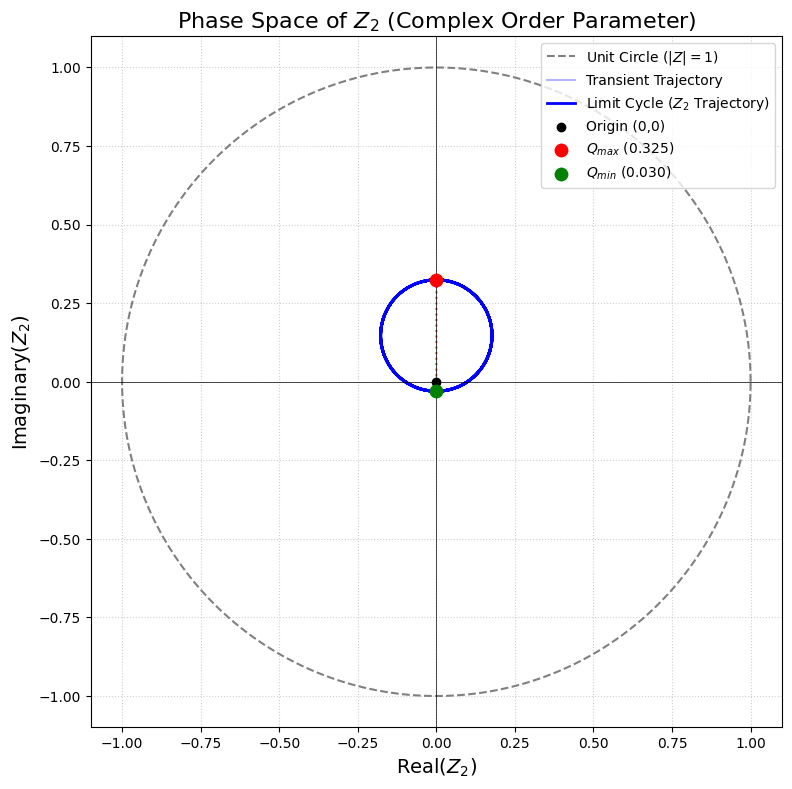

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. 파라미터 설정 (Limit cycle이 생기는 조건: sin(alpha) > mu^2)
alpha = 1.0       # sin(1.0) ≒ 0.841
mu = 0.5          # mu^2 = 0.25
eta = 0.1         # eta_sigma'

# 공통 상수 A, B 계산
A = (mu**2) * (1 - 2*eta)**2
B = np.sin(alpha) * (1 - 2*eta)**2

# 2. 복소 리카티 미분방정식 정의 (Z = Z_real + 1j * Z_imag)
def complex_riccati(t, Z_flat):
    Z = Z_flat[0] + 1j * Z_flat[1]
    dZ_dt = A * (1 - Z**2) + 2j * B * Z
    return [dZ_dt.real, dZ_dt.imag]

# 3. 시뮬레이션 수행
t_span = (0, 50)
t_eval = np.linspace(0, 50, 5000)
# 초기 조건: 원점 근처에서 출발 (예: 진폭이 작고 위상이 0인 상태)
Z0 = [0.1, 0.0]  

sol = solve_ivp(complex_riccati, t_span, Z0, t_eval=t_eval, method='RK45')
Z_sim = sol.y[0] + 1j * sol.y[1]

# 4. 분석적(Analytical) 최대/최소 계산 (검증용)
# Z = r^2 exp(i*Phi) 이므로, 절대값 |Z|가 곧 거시적 진폭 Q의 크기를 의미합니다.
Q_sim = np.abs(Z_sim)
Q_max_idx = np.argmax(Q_sim)
Q_min_idx = np.argmin(Q_sim[1000:]) + 1000 # 초기 과도응답(Transient) 제외

Z_max = Z_sim[Q_max_idx]
Z_min = Z_sim[Q_min_idx]

# ==========================================
# 5. 위상 공간(Phase Space) 시각화
# ==========================================
plt.figure(figsize=(8, 8))

# (1) 배경: 반지름 1인 단위 원반 (Unit Disk) 그리기
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', label='Unit Circle ($|Z|=1$)')

# (2) 시뮬레이션 궤적 (Limit Cycle)
# 초기 과도응답 부분은 흐리게, 안정화된 Limit cycle 부분은 진하게 표시
plt.plot(Z_sim[:500].real, Z_sim[:500].imag, color='blue', alpha=0.3, label='Transient Trajectory')
plt.plot(Z_sim[500:].real, Z_sim[500:].imag, color='blue', linewidth=2, label='Limit Cycle ($Z_2$ Trajectory)')

# (3) 원점, Q_max, Q_min 포인트 마킹
plt.scatter([0], [0], color='black', zorder=5, label='Origin (0,0)')
plt.scatter([Z_max.real], [Z_max.imag], color='red', s=80, zorder=5, label=f'$Q_{{max}}$ ({np.abs(Z_max):.3f})')
plt.scatter([Z_min.real], [Z_min.imag], color='green', s=80, zorder=5, label=f'$Q_{{min}}$ ({np.abs(Z_min):.3f})')

# (4) 중심을 관통하는 축 (Q_max와 Q_min을 잇는 선)
plt.plot([0, Z_max.real], [0, Z_max.imag], color='red', linestyle=':', alpha=0.7)
plt.plot([0, Z_min.real], [0, Z_min.imag], color='green', linestyle=':', alpha=0.7)

# (5) 그래프 꾸미기
plt.title("Phase Space of $Z_2$ (Complex Order Parameter)", fontsize=16)
plt.xlabel("Real($Z_2$)", fontsize=14)
plt.ylabel("Imaginary($Z_2$)", fontsize=14)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [77]:
eta1

0.4

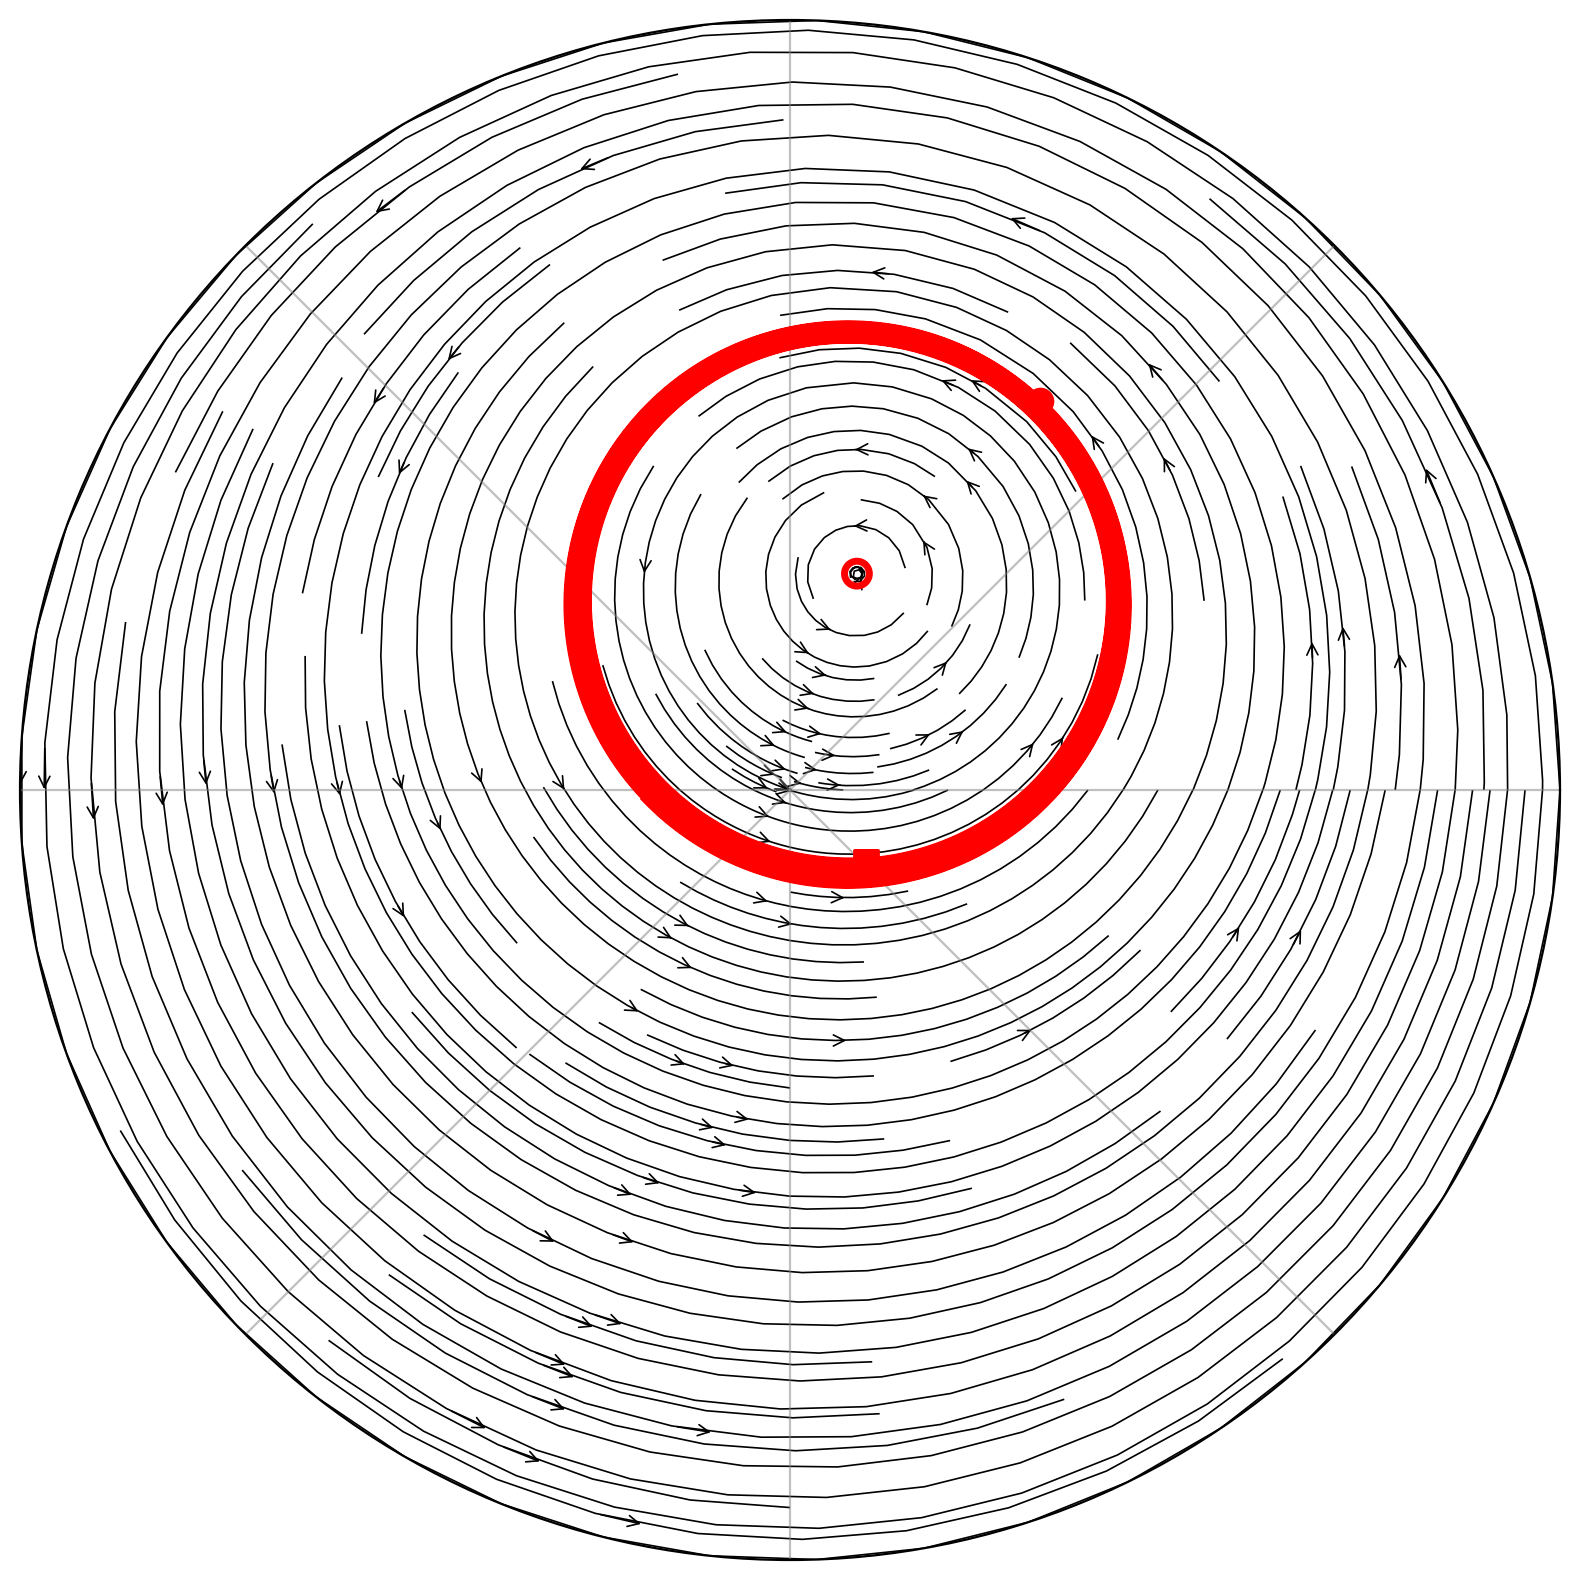

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. 파라미터 설정 (Limit cycle이 존재하는 조건)
# ==========================================
# alpha = 1.0       # alpha 값
# mu = 0.4         # beta (논문에서의 mu)
eta = eta1         # eta1, eta2 (단순화를 위해 동일하게 설정)

A = (mu**2) * (1 - 2*eta)**2
B = np.sin(alpha) * (1 - 2*eta)**2

# ==========================================
# 2. 벡터 필드 (Vector Field) 정의 (Streamplot 용)
# ==========================================
# 극좌표계 그리드 생성 (각도: 2*phi, 반지름: Q=r^2)
# 중심점(0)에서의 발산을 막기 위해 반지름은 0.001부터 시작합니다.
theta_grid = np.linspace(0, 2*np.pi, 200)
rho_grid = np.linspace(0.001, 1.0, 200)
T, R = np.meshgrid(theta_grid, rho_grid)

# 방정식: d(rho)/dt 와 d(theta)/dt
# Z = rho * exp(i*(Theta + alpha)) 이므로 Theta = 2*phi
dRho = A * (1 - R**2) * np.cos(T + alpha)
dTheta = -A * ((1 + R**2) / R) * np.sin(T + alpha) + 2 * B

# ==========================================
# 3. 궤적 (Trajectory) 시뮬레이션 (Limit Cycle 용)
# ==========================================
def complex_riccati(t, Z_flat):
    Z = Z_flat[0] + 1j * Z_flat[1]
    dZ = A * (1 - Z**2) + 2j * B * Z
    return [dZ.real, dZ.imag]

# 초기 조건 (빨간색 꽉 찬 동그라미 위치)
Q_init = 0.6
phi_init = shift
Z0 = [Q_init * np.cos(phi_init + alpha), Q_init * np.sin(phi_init + alpha)]

t_span = (0, 10000)
t_eval = np.linspace
sol = solve_ivp(complex_riccati, t_span, Z0, t_eval=t_eval, method='RK45')

# 시뮬레이션 결과를 극좌표용으로 변환 (rho, theta)
Z_complex = sol.y[0] + 1j * sol.y[1]
rho_traj = np.abs(Z_complex)
theta_traj = np.unwrap(np.angle(Z_complex)) - alpha 

# ==========================================
# 4. 내부 고정점 (Fixed Point / Center) 계산
# ==========================================
# Z_fp = i * (B - sqrt(B^2 - A^2)) / A
rho_fp = (B - np.sqrt(B**2 - A**2)) / A
theta_fp = np.pi/2 - alpha

# ==========================================
# 5. 시각화 (Plotting)
# ==========================================
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8), dpi=200)

# 배경 유선 (Streamlines)
ax.streamplot(T, R, dTheta, dRho, color='k', linewidth=0.6, density=1.5, arrowstyle='->', zorder=1)

# Limit cycle 궤적 (빨간 선)
# 과도응답(Transient)을 제외한 뒷부분만 진하게 그리기
ax.plot(theta_traj[500:] % (2*np.pi), rho_traj[500:], color='red', linewidth=3.5, zorder=4)

# 마커 표시 (Start, End, Center)
# 1) 시작점 (Solid Red Circle)
c = ax.scatter(theta_traj[0] % (2*np.pi), rho_traj[0], s=80, color='red', zorder=5, label='Start')
# 2) 끝점 (Solid Red Square)
ax.scatter(theta_traj[-1] % (2*np.pi), rho_traj[-1], s=80, marker='s', color=c.get_facecolor(), zorder=5, label='End')
# 3) 고정점/중심 (Hollow Red Circle)
ax.scatter(theta_fp, rho_fp, s=80, facecolors='none', edgecolors='red', linewidths=2.5, zorder=6, label='Center FP')

# 그래프 스타일링 (보내주신 예시와 동일한 감성)
ax.set_ylim(0, 1.0) # 반지름 한계는 1 (Unit Disk)
ax.set_yticks([])   # 내부 원형 그리드 숫자 숨기기
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 6*np.pi/4, 7*np.pi/4])
ax.set_xticklabels(['', '', '', '', '', '', '', '']) # 각도 숫자 숨기기
ax.grid(True, linestyle='-', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()

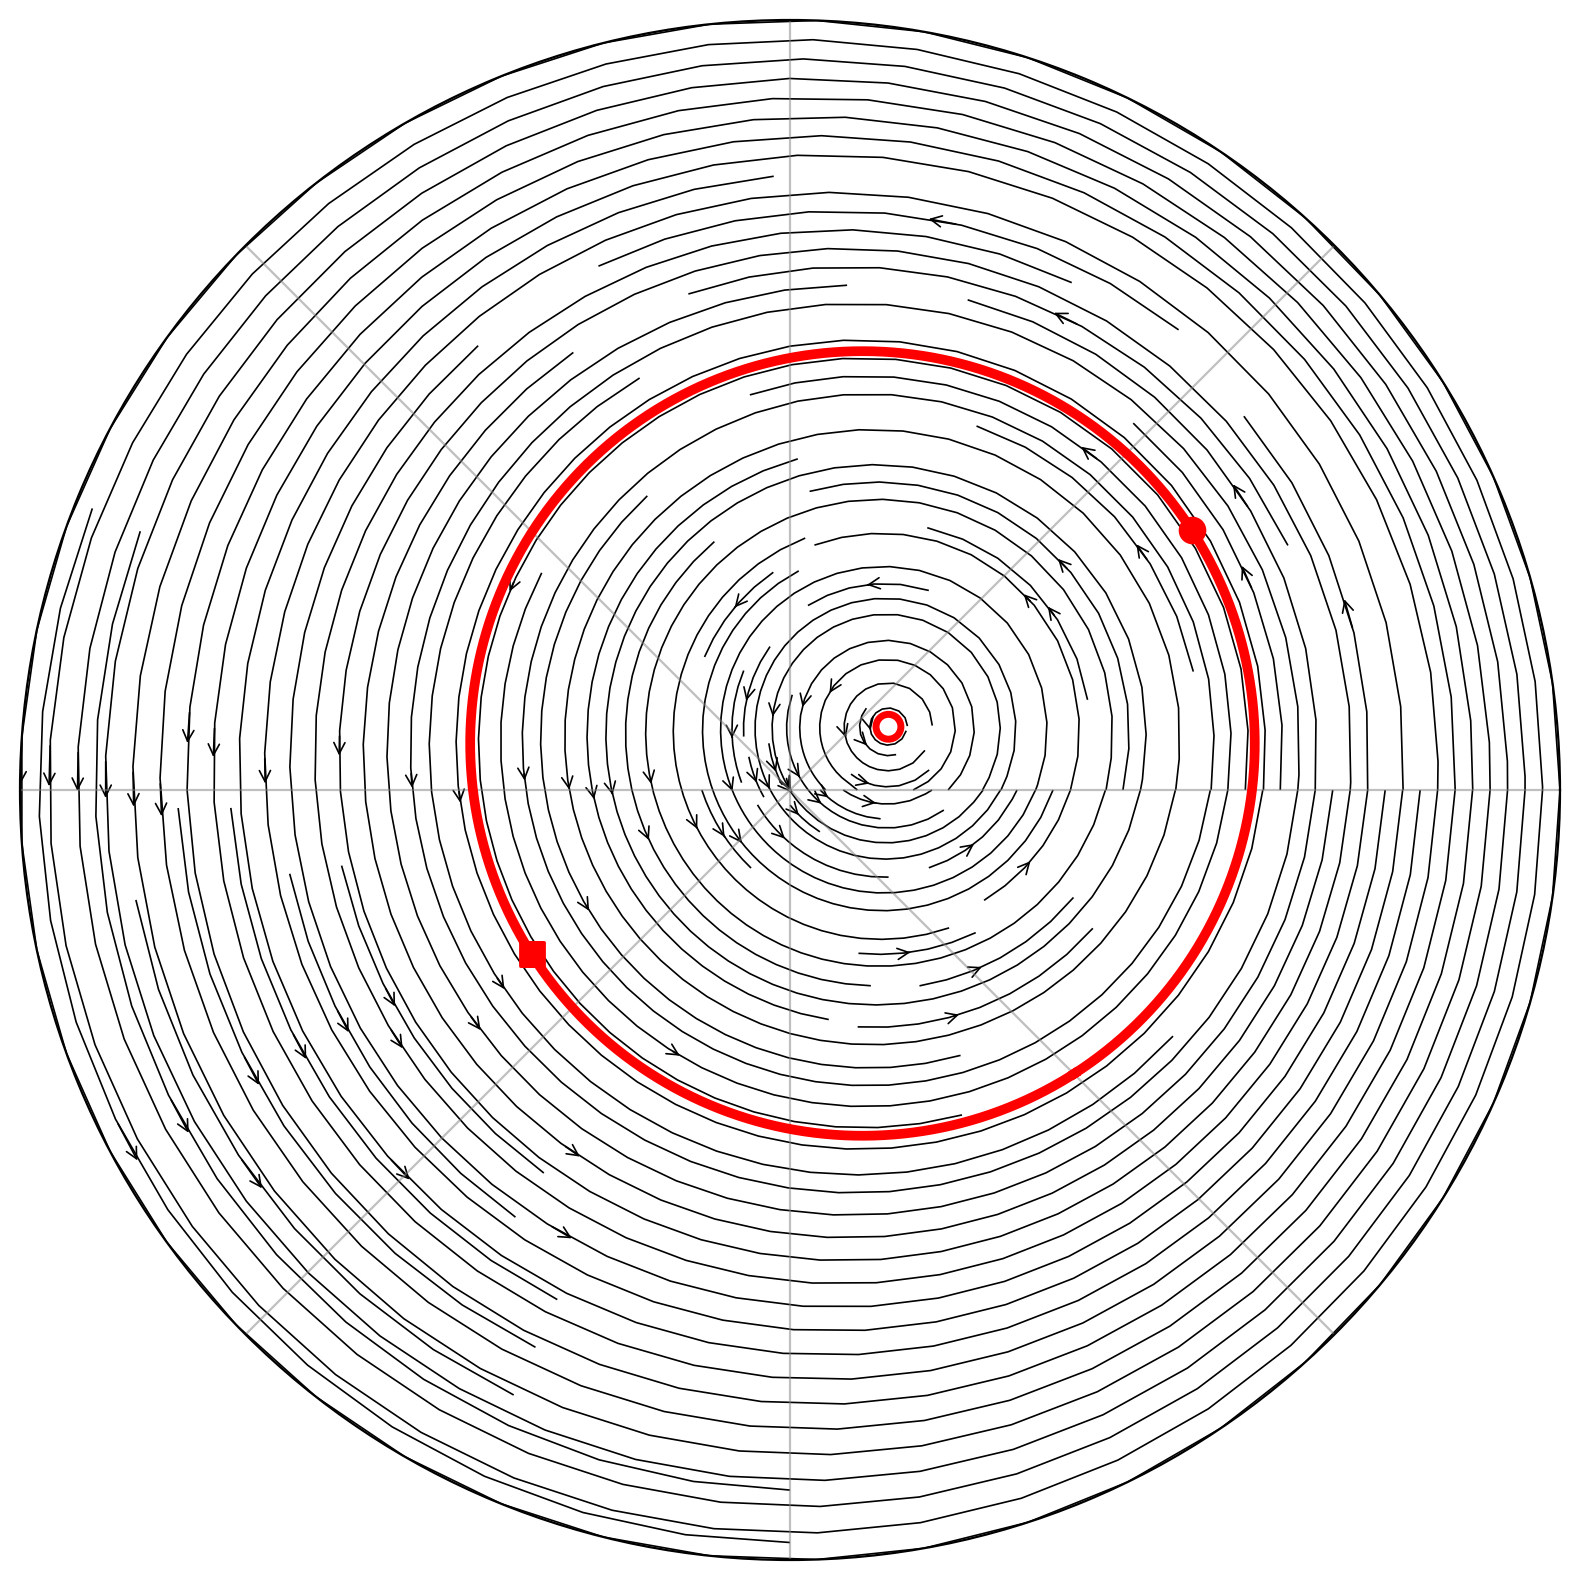

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 파라미터 및 초기 조건 설정
# ==========================================
alpha = 1.0       
mu = 0.5          
eta = 0.1         

A = (mu**2) * (1 - 2*eta)**2
B = np.sin(alpha) * (1 - 2*eta)**2

# 궤도 보존량 C_0를 구하기 위한 초기 상태
Q_init = 0.6
phi_init = 0.0

# ==========================================
# 2. Z_2의 해석적 해 (Analytical Solution) 도출 
# - ODE 시뮬레이션(RK45)을 전혀 사용하지 않습니다!
# ==========================================
# (1) 초기 상태를 바탕으로 불변량 C_0 계산
Y_init = Q_init * np.sin(2 * phi_init + alpha)
C_0 = (np.sin(alpha) - mu**2 * Y_init) / (1 - Q_init**2)

# (2) 위상 공간에서 형성되는 완벽한 원의 중심과 반지름
Center_Y = (mu**2) / (2 * C_0)
Radius = np.sqrt(mu**4 - 4 * C_0 * (np.sin(alpha) - C_0)) / (2 * C_0)

# (3) 0 ~ 2pi를 도는 매개변수로 원 궤적(Z) 생성
theta_circ = np.linspace(0, 2*np.pi, 500)
# 중심이 허수축(Y)에 Center_Y만큼 치우친 반경 Radius의 원
Z_analytical = 1j * Center_Y + Radius * np.exp(1j * theta_circ)

# (4) Z를 Z_2 극좌표계(Q, 2*phi)로 완벽 매핑
Q_exact = np.abs(Z_analytical)
Theta_exact = np.unwrap(np.angle(Z_analytical)) - alpha

# 고정점(Center)도 해석적으로 계산
rho_fp = (B - np.sqrt(B**2 - A**2)) / A
theta_fp = np.pi/2 - alpha

# ==========================================
# 3. 위상 공간 시각화 (Polar Phase Space Plot)
# ==========================================
# (배경 Streamplot용 그리드 생성 - 이전과 동일)
theta_grid = np.linspace(0, 2*np.pi, 200)
rho_grid = np.linspace(0.001, 1.0, 200)
T, R_grid = np.meshgrid(theta_grid, rho_grid)
dRho = A * (1 - R_grid**2) * np.cos(T + alpha)
dTheta = -A * ((1 + R_grid**2) / R_grid) * np.sin(T + alpha) + 2 * B

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8), dpi=200)

# 배경 유선 (Streamlines)
ax.streamplot(T, R_grid, dTheta, dRho, color='k', linewidth=0.6, density=1.5, arrowstyle='->', zorder=1)

# ★ 미분방정식 수치해석 없이 닫힌 수식으로 그린 완벽한 Limit cycle 궤적 ★
ax.plot(Theta_exact % (2*np.pi), Q_exact, color='red', linewidth=3.5, zorder=4)

# 고정점(Center) 마킹 (빈 동그라미)
ax.scatter(theta_fp, rho_fp, s=80, facecolors='none', edgecolors='red', linewidths=2.5, zorder=6)

# 최댓값, 최솟값 마킹 (선택 사항: 원의 지름 양 끝점)
Q_max_idx = np.argmax(Q_exact)
Q_min_idx = np.argmin(Q_exact)
ax.scatter(Theta_exact[Q_max_idx] % (2*np.pi), Q_exact[Q_max_idx], s=80, color='red', zorder=5, marker='o') # 최대 진폭점
ax.scatter(Theta_exact[Q_min_idx] % (2*np.pi), Q_exact[Q_min_idx], s=80, color='red', zorder=5, marker='s') # 최소 진폭점

# 그래프 스타일링
ax.set_ylim(0, 1.0) 
ax.set_yticks([])   
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 6*np.pi/4, 7*np.pi/4])
ax.set_xticklabels(['', '', '', '', '', '', '', '']) 
ax.grid(True, linestyle='-', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
alpha = 0.3
beta = 0.5
Q1 = 1
shift =1
eta1 = 0.45
Q2 = 0.6
eta2 = 0.5
R1s, R2s, Q1s, Q2s,t = get_RQ_OA(Q1, Q2, alpha, beta, eta1, eta2, omega=0.0, shift=shift, t_end=1e7, dt=0.01)

In [124]:
alphas = np.linspace(0,np.pi/2,1000)
betas = np.linspace(0,1,1001)[1:]
shift = 0
A,B = np.meshgrid(alphas,betas)

In [125]:
O = (1-2*eta1)**2*np.sqrt(np.sin(A)**2-B**4)
P = np.pi/O

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\4012893600.py:1: RuntimeWarning: invalid value encountered in sqrt
  O = (1-2*eta1)**2*np.sqrt(np.sin(A)**2-B**4)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\4012893600.py:2: RuntimeWarning: divide by zero encountered in divide
  P = np.pi/O


C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\1361562611.py:2: RuntimeWarning: invalid value encountered in sqrt
  O_alpha = (1-2*eta1)**2*np.sqrt(np.sin(alpha)**2-betas**4)


Text(0, 0.5, 'Period')

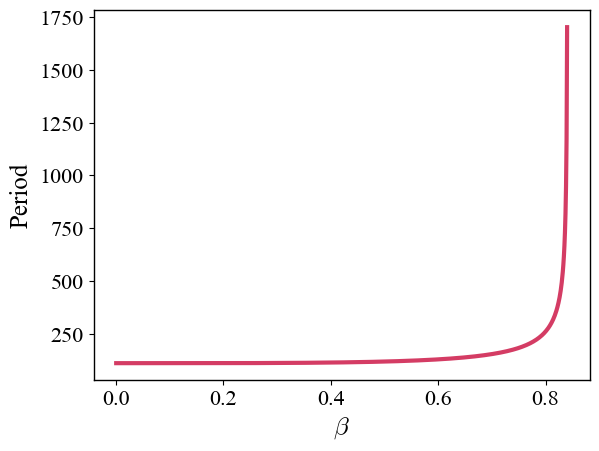

In [126]:
alpha = np.pi/4
O_alpha = (1-2*eta1)**2*np.sqrt(np.sin(alpha)**2-betas**4)
P_alpha = np.pi/O_alpha
finite_mask = np.isfinite(P_alpha) & (P_alpha > 0)
P_alpha_plot = np.where(finite_mask, P_alpha, np.nan)
plt.plot(betas,P_alpha_plot,lw=3,color='#d43c64')
plt.xlabel(r'$\beta$')
plt.ylabel(r'Period')
# plt.yscale('log')

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\34828667.py:2: RuntimeWarning: invalid value encountered in sqrt
  O_beta = (1-2*eta1)**2*np.sqrt(np.sin(alphas)**2-beta**4)


Text(0, 0.5, 'Period')

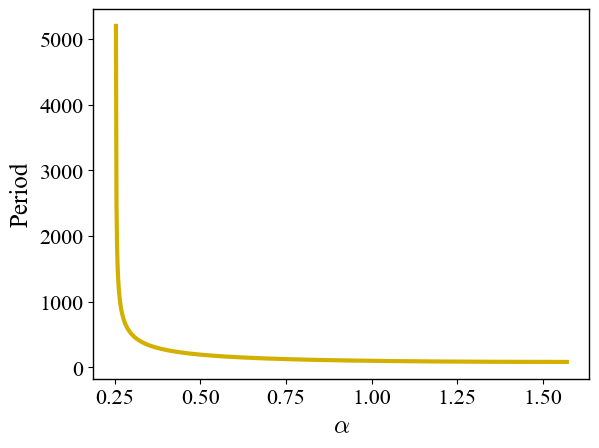

In [127]:
beta = 0.5
O_beta = (1-2*eta1)**2*np.sqrt(np.sin(alphas)**2-beta**4)
P_beta = np.pi/O_beta
finite_mask = np.isfinite(P_beta) & (P_beta > 0)
P_beta_plot = np.where(finite_mask, P_beta, np.nan)
plt.plot(alphas,P_beta_plot,lw=3,color='#d3b000')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'Period')

Text(0, 0.5, '$\\mu$')

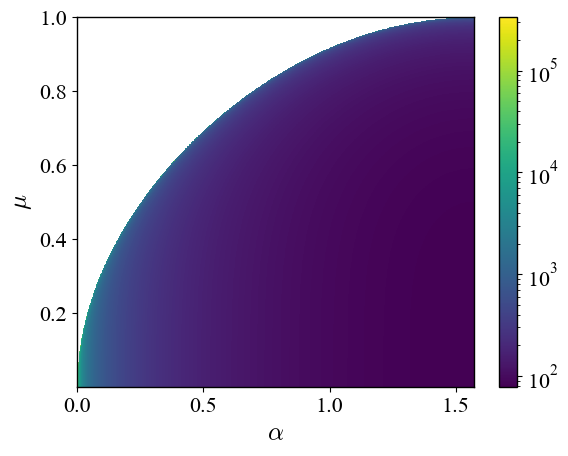

In [128]:
from matplotlib.colors import LogNorm
import numpy as np

# Remove invalid or non-finite values from P, A, B before plotting
finite_mask = np.isfinite(P) & (P > 0)
# Set P values that are not finite or <=0 to np.nan (to be safely ignored by pcolormesh)
P_plot = np.where(finite_mask, P, np.nan)

# Optionally, adjust vmin and vmax based on actual finite values
finite_P_vals = P[finite_mask]
if finite_P_vals.size > 0:
    P_vmin = np.nanmax([np.nanmin(finite_P_vals), 1e-3])
    P_vmax = np.nanmax(finite_P_vals)
else:
    P_vmin = 1e-3
    P_vmax = 1.0
plt.pcolormesh(A,B,P_plot,norm=LogNorm(vmin=P_vmin,vmax=P_vmax))

plt.colorbar()
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\mu$')

Text(0, 0.5, '$\\Delta Q$')

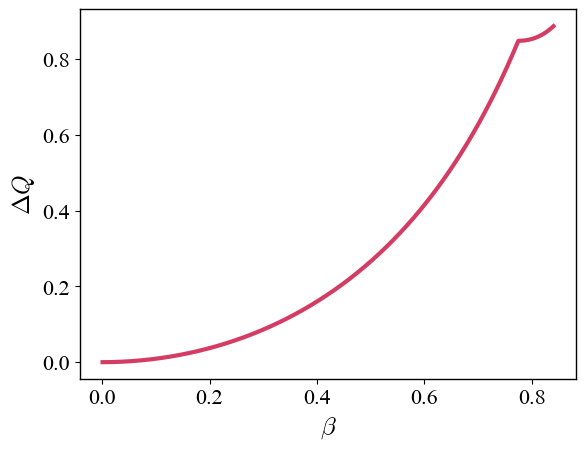

In [129]:
alpha = np.pi/4
filter = betas<np.sqrt(np.sin(alpha))
C_0 = (np.sin(alpha) - betas**2 * Q2 * np.sin(-2*shift + alpha))/(1-Q2**2)
Q_max = (betas**2 + np.sqrt(betas**4 - 4*C_0*(np.sin(alpha) - C_0)))/(2*C_0)
Q_min = abs(betas**2 - np.sqrt(betas**4 - 4*C_0*(np.sin(alpha) - C_0)))/(2*C_0)
DQ = Q_max-Q_min
plt.plot(betas[filter],DQ[filter],lw=3,color='#d43c64')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\Delta Q$')

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\2580165067.py:4: RuntimeWarning: divide by zero encountered in divide
  Q_max = (beta**2 + np.sqrt(beta**4 - 4*C_0*(np.sin(alphas) - C_0)))/(2*C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\2580165067.py:5: RuntimeWarning: invalid value encountered in divide
  Q_min = abs(beta**2 - np.sqrt(beta**4 - 4*C_0*(np.sin(alphas) - C_0)))/(2*C_0)


Text(0, 0.5, '$\\Delta Q$')

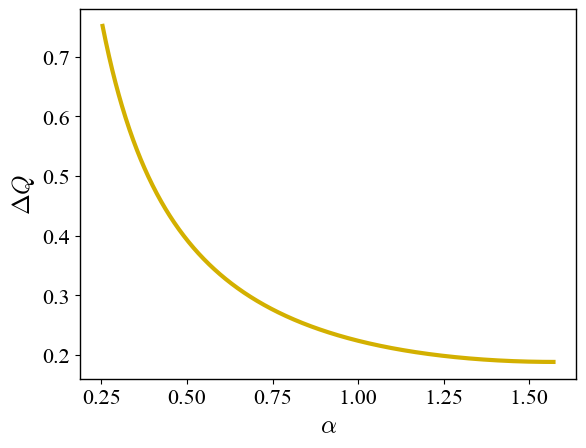

In [132]:
beta = 0.5
filter = beta<np.sqrt(np.sin(alphas))
C_0 = (np.sin(alphas) - beta**2 * Q2 * np.sin(-2*shift + alphas))/(1-Q2**2)
Q_max = (beta**2 + np.sqrt(beta**4 - 4*C_0*(np.sin(alphas) - C_0)))/(2*C_0)
Q_min = abs(beta**2 - np.sqrt(beta**4 - 4*C_0*(np.sin(alphas) - C_0)))/(2*C_0)
DQ = Q_max-Q_min
# plt.plot(betas,DQ,lw=3,color='#d43c64')
plt.plot(alphas[filter],DQ[filter],lw=3,color='#d3b000')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\Delta Q$')

In [131]:
mu = B
shift = 0
C_0 = (np.sin(A) - B**2 * Q2 * np.sin(-2*shift + A))/(1-Q2**2)
Q_max = (mu**2 + np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\3455198856.py:4: RuntimeWarning: divide by zero encountered in divide
  Q_max = (mu**2 + np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\3455198856.py:5: RuntimeWarning: divide by zero encountered in divide
  Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\3455198856.py:5: RuntimeWarning: invalid value encountered in divide
  Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)


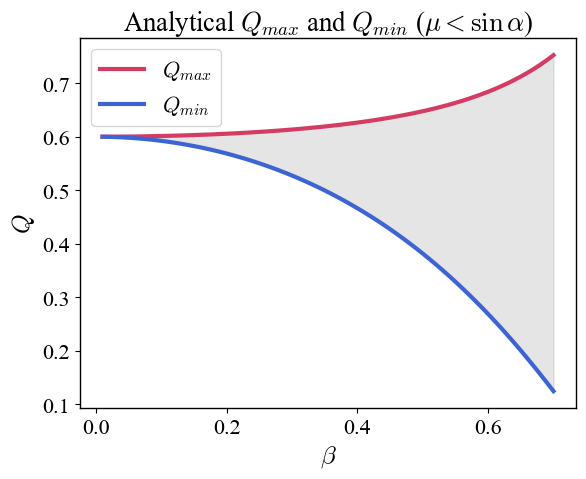

In [116]:
import numpy as np
import matplotlib.pyplot as plt

# 파라미터 및 초기 조건 설정
alpha = np.pi/4
shift = 0.0
Q2_init = 0.6  # 시뮬레이션에서 사용한 Q2의 초기값

# mu를 betas 배열로 설정 (기존 코드와의 호환성을 위해)
mu = betas 

# 보존량 C_0 및 루트 안의 판별식(D) 계산
C_0 = (np.sin(alpha) - mu**2 * Q2_init * np.sin(-2*shift + alpha)) / (1 - Q2_init**2)
D = mu**4 - 4 * C_0 * (np.sin(alpha) - C_0)

# ==========================================
# 핵심 마스킹 조건 적용
# 1) 요청하신 조건: mu < sin(alpha)
# 2) 수학적 조건: 루트 안의 값(D)이 0 이상일 것, C_0가 0이 아닐 것
# ==========================================
valid_mask = (mu < np.sin(alpha)) & (D >= 0) & (C_0 != 0)

# 에러 방지를 위해 마스크 밖의 D값을 임시로 0으로 치환 (계산 후 np.nan으로 덮어씌워짐)
D_safe = np.where(valid_mask, D, 0)

# 해석적 Q_max, Q_min 계산
Q_max_raw = (mu**2 + np.sqrt(D_safe)) / (2 * C_0)
Q_min_raw = np.abs(mu**2 - np.sqrt(D_safe)) / (2 * C_0)

# valid_mask를 이용해 조건에 맞지 않는 구간을 np.nan으로 처리
Q_max_plot = np.where(valid_mask, Q_max_raw, np.nan)
Q_min_plot = np.where(valid_mask, Q_min_raw, np.nan)

# ==========================================
# 플롯 그리기
# ==========================================
plt.plot(mu, Q_max_plot, lw=3, color='#d43c64', label=r'$Q_{max}$')
plt.plot(mu, Q_min_plot, lw=3, color='#3c64d4', label=r'$Q_{min}$')

# 두 선 사이 색칠 (선택 사항)
plt.fill_between(mu, Q_min_plot, Q_max_plot, color='gray', alpha=0.2)

plt.xlabel(r'$\beta$')
plt.ylabel(r'$Q$')
plt.title(r'Analytical $Q_{max}$ and $Q_{min}$ ($\mu < \sin\alpha$)')
plt.legend()
plt.show()

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\3533791761.py:4: RuntimeWarning: invalid value encountered in subtract
  DQ = Q_max-Q_min


Text(0, 0.5, '$\\mu$')

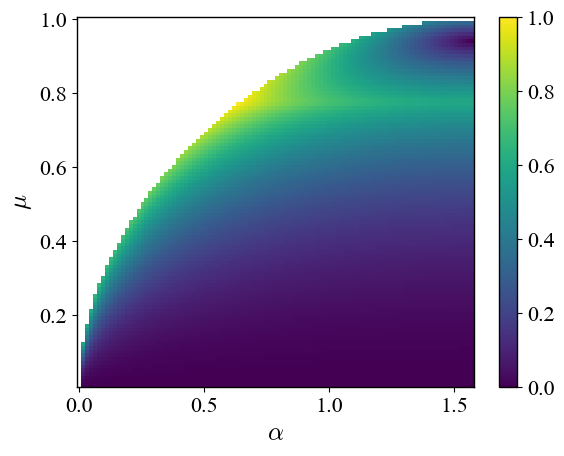

In [ ]:
alphas = np.linspace(0,np.pi/2,1000)
betas = np.linspace(0,1,1001)[1:]
shift = 0
A,B = np.meshgrid(alphas,betas)

finite_mask = np.isfinite(P) & (P > 0)
# Set P values that are not finite or <=0 to np.nan (to be safely ignored by pcolormesh)

DQ = Q_max-Q_min
DQ_plot = np.where(finite_mask, DQ, np.nan)

plt.pcolormesh(A,B,DQ_plot,vmin=0,vmax=1)
plt.colorbar()
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\mu$')

In [ ]:
mu = B
shift = 0
C_0 = (np.sin(A) - B**2 * Q2 * np.sin(-2*shift + A))/(1-Q2**2)
Q_max = (mu**2 + np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0) 

In [ ]:
alpha = np.pi/4



O_alpha = (1-2*eta1)**2*np.sqrt(np.sin(alpha)**2-betas**4)
P_alpha = np.pi/O_alpha
finite_mask = np.isfinite(P_alpha) & (P_alpha > 0)
P_alpha_plot = np.where(finite_mask, P_alpha, np.nan)
plt.plot(betas,P_alpha_plot,lw=3,color='#d43c64')
plt.xlabel(r'$\beta$')
plt.ylabel(r'Period')
# plt.yscale('log')

# Shift

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\1254967150.py:6: RuntimeWarning: divide by zero encountered in divide
  Q_max = (mu**2 + np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\1254967150.py:7: RuntimeWarning: divide by zero encountered in divide
  Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\1254967150.py:7: RuntimeWarning: invalid value encountered in divide
  Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\1254967150.py:8: RuntimeWarning: invalid value encountered in subtract
  DQ = Q_max-Q_min


Text(0, 0.5, '$\\mu$')

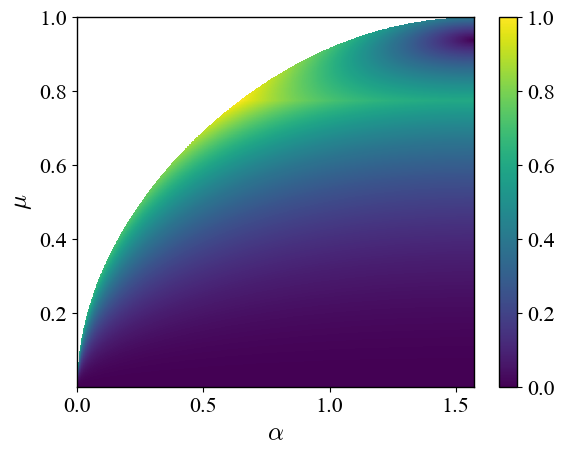

In [135]:
finite_mask = np.isfinite(P) & (P > 0)
# Set P values that are not finite or <=0 to np.nan (to be safely ignored by pcolormesh)
mu = B
shift = 0
C_0 = (np.sin(A) - B**2 * Q2 * np.sin(-2*shift + A))/(1-Q2**2)
Q_max = (mu**2 + np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0)
Q_min = abs(mu**2 - np.sqrt(mu**4 - 4*C_0*(np.sin(A) - C_0)))/(2*C_0) 
DQ = Q_max-Q_min
DQ_plot = np.where(finite_mask, DQ, np.nan)

plt.pcolormesh(A,B,DQ_plot,vmin=0,vmax=1)
plt.colorbar()
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\mu$')

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML # Jupyter에서 바로 보기 위함

# 1. 초기 설정 (A, B는 meshgrid, finite_mask는 이전 코드에서 정의되었다고 가정)
# Q2 = 0.6  # 시뮬레이션에서 사용했던 Q2 초기값 (필요시 지정)

fig, ax = plt.subplots(figsize=(7, 6))

# 첫 번째 프레임(shift=0) 초기 렌더링
shift_init = 0.0
C_0 = (np.sin(A) - B**2 * Q2 * np.sin(-2*shift_init + A)) / (1 - Q2**2)
D = B**4 - 4 * C_0 * (np.sin(A) - C_0)

# 유효 범위 마스크 (기존 P에 대한 finite_mask + 루트 안이 양수 + C_0가 0이 아님)
valid_mask = finite_mask & (D >= 0) & (C_0 != 0)

D_safe = np.maximum(D, 0) # 루트 안 음수 에러 방지
Q_max = (B**2 + np.sqrt(D_safe)) / (2 * C_0)
Q_min = np.abs(B**2 - np.sqrt(D_safe)) / (2 * C_0)
DQ = Q_max - Q_min

DQ_plot = np.where(valid_mask, DQ, np.nan)

# pcolormesh 객체 생성 (이 객체의 데이터를 매 프레임 업데이트 합니다)
cax = ax.pcolormesh(A, B, DQ_plot, vmin=0, vmax=1.0, shading='auto', cmap='viridis')
fig.colorbar(cax, ax=ax, label=r'$\Delta Q$ (Amplitude)')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\mu$ ($\beta$)')

# 애니메이션 중 계속 바뀔 타이틀 텍스트 객체
title = ax.set_title(f'Shift = {shift_init:.2f} rad')

# 2. 업데이트 함수 정의 (매 프레임마다 호출됨)
def update(frame_shift):
    # 새로운 shift 값에 대해 해석적 해 다시 계산
    C_0_new = (np.sin(A) - B**2 * Q2 * np.sin(-2*frame_shift + A)) / (1 - Q2**2)
    D_new = B**4 - 4 * C_0_new * (np.sin(A) - C_0_new)
    
    mask_new = finite_mask & (D_new >= 0) & (C_0_new != 0)
    D_safe_new = np.maximum(D_new, 0)
    
    Q_max_new = (B**2 + np.sqrt(D_safe_new)) / (2 * C_0_new)
    Q_min_new = np.abs(B**2 - np.sqrt(D_safe_new)) / (2 * C_0_new)
    DQ_new = Q_max_new - Q_min_new
    
    DQ_plot_new = np.where(mask_new, DQ_new, np.nan)
    
    # 데이터만 교체 (새로 그리는 것보다 연산이 훨씬 빠름)
    cax.set_array(DQ_plot_new.ravel())
    title.set_text(f'Shift = {frame_shift:.2f} rad')
    
    return cax, title

# 3. 애니메이션 생성 (0 ~ 2pi 까지 60 프레임)
shifts_array = np.linspace(0, 2*np.pi, 120)
ani = FuncAnimation(fig, update, frames=shifts_array, interval=100, blit=False)

# 4. Jupyter Notebook에서 애니메이션 띄우기
plt.close(fig) # 정지된 중복 그래프가 뜨는 것을 방지
display(HTML(ani.to_html5_video()))

C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\325049966.py:20: RuntimeWarning: divide by zero encountered in divide
  Q_max = (B**2 + np.sqrt(D_safe)) / (2 * C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\325049966.py:21: RuntimeWarning: divide by zero encountered in divide
  Q_min = np.abs(B**2 - np.sqrt(D_safe)) / (2 * C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\325049966.py:21: RuntimeWarning: invalid value encountered in divide
  Q_min = np.abs(B**2 - np.sqrt(D_safe)) / (2 * C_0)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\325049966.py:22: RuntimeWarning: invalid value encountered in subtract
  DQ = Q_max - Q_min
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\325049966.py:44: RuntimeWarning: divide by zero encountered in divide
  Q_max_new = (B**2 + np.sqrt(D_safe_new)) / (2 * C_0_new)
C:\Users\kim9y\AppData\Local\Temp\ipykernel_53852\325049966.py:45: RuntimeWarning: divide by zero encountered in divide
  Q_min_new = np.abs(B**2 - np.sqrt(D_safe_new)

# PERIOD and min max

In [27]:
from tqdm.notebook import tqdm
from parfor import parfor

In [ ]:
alpha = 0.3
beta = 0.5
Q1 = 1
shift =1
eta1 = 0.4
Q2 = 0.6
eta2 = 0.5
R1s, R2s, Q1s, Q2s,t = get_RQ_OA(Q1, Q2, alpha, beta, eta1, eta2, omega=0.0, shift=shift, t_end=5000, dt=0.01)

In [7]:
O = (1-2*eta1)**2*np.sqrt(np.sin(alpha)**2-beta**4)
P = np.pi/O
print(P)

498.4049510273661


In [ ]:
def calculate_period_from_data(data, time_array):
    # 데이터에서 극댓값(peak)들의 인덱스를 찾습니다.
    peaks, _ = find_peaks(data)
    
    # 극댓값이 2개 이상 찾아졌을 때만 주기 계산이 가능합니다.
    if len(peaks) > 1:
        # 극댓값들이 발생한 시간(t)의 차이(diff)를 구합니다.
        peak_times = time_array[peaks]
        periods = np.diff(peak_times)
        
        # 주기들의 평균을 내어 보다 안정적인 주기 값을 얻습니다.
        average_period = np.mean(periods)
        return average_period
    else:
        return np.nan

# Q1 질서 매개변수 시계열 데이터로 주기를 계산합니다.
simulated_period = calculate_period_from_data(Q2s, t)

if simulated_period:
    print(f"시뮬레이션으로 측정한 평균 주기: {simulated_period:.4f}")
else:
    print("충분한 진동이 발생하지 않았습니다 (Fixed point에 수렴했거나 시뮬레이션 시간이 너무 짧음).")

시뮬레이션으로 측정한 평균 주기: 498.4044


In [96]:
Q1 = 1
shift =0
eta1 = 0.4
Q2 = 0.6
eta2 = 0.5

In [97]:
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]

In [98]:
# [수정 3] 외부 저장용 리스트의 이름을 명확히 변경 (변수 덮어쓰기 방지)
Q_MIN_LIST = []
Q_MAX_LIST = []
DQ_LIST = []
P_LIST = []

for beta in tqdm(betas):
    @parfor(alphas, args=(beta,), bar=False)
    def get_MIN_MAX_DQ_P(alpha, beta):
        R1s, R2s, Q1s, Q2s, t = get_RQ_OA(Q1, Q2, alpha, beta, eta1, eta2, omega=0.0, shift=shift, t_end=10000, dt=0.1)
        
        # [수정 2] 상태값과 시간 배열을 동일한 길이로 잘라주어 인덱스 싱크를 맞춥니다.
        Q2s_steady = Q2s[5000:]
        t_steady = t[5000:]
        
        # [수정 1] 함수가 단일 값을 반환하므로 튜플 언패킹(,)을 하지 않고 바로 받습니다.
        P_val = calculate_period_from_data(Q2s_steady, t_steady)
        
        Q_max = np.max(Q2s_steady)
        Q_min = np.min(Q2s_steady)
        delta_q = Q_max - Q_min
        
        return Q_min, Q_max, delta_q, P_val
    
    # parfor 결과를 반환받을 때 임시 변수명을 사용하여 리스트와 겹치지 않게 합니다.
    q_mins, q_maxs, dqs, ps = zip(*get_MIN_MAX_DQ_P)
    
    Q_MIN_LIST.append(q_mins)
    Q_MAX_LIST.append(q_maxs)
    DQ_LIST.append(dqs)
    P_LIST.append(ps)


  0%|          | 0/100 [00:00<?, ?it/s]

In [104]:
P_array = np.array(P_LIST)
DQ_array = np.array(DQ_LIST)
Q_MIN_array = np.array(Q_MIN_LIST)
Q_MAX_array = np.array(Q_MAX_LIST)
P_array = np.where(P_array == None, np.nan, P_array).astype(float)
DQ_array = np.where(DQ_array == None, np.nan, DQ_array).astype(float)

In [105]:
A,B = np.meshgrid(alphas,betas)
FIRTER = B<np.sqrt(np.sin(A))
P_array = np.where(FIRTER,P_array,np.nan)
DQ_array = np.where(FIRTER,DQ_array,np.nan)
Q_min_array = np.where(FIRTER,Q_MIN_array,np.nan)
Q_max_array = np.where(FIRTER,Q_MAX_array,np.nan)

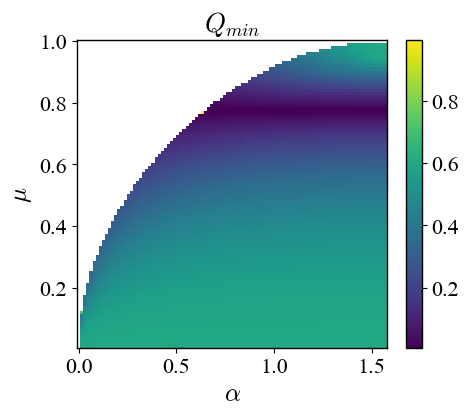

In [106]:
plt.figure(figsize=(5,4))
plt.pcolormesh(alphas,betas,Q_min_array)
plt.colorbar()
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\mu$')
plt.title(r'$Q_{min}$')
plt.show()

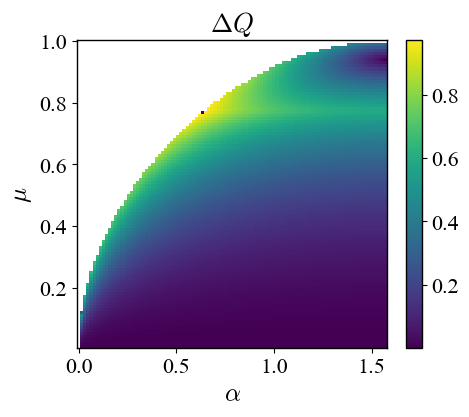

In [107]:
plt.figure(figsize=(5,4))
plt.pcolormesh(alphas,betas,DQ_array)
plt.colorbar()
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\mu$')
plt.title(r'$\Delta Q$')
plt.show()

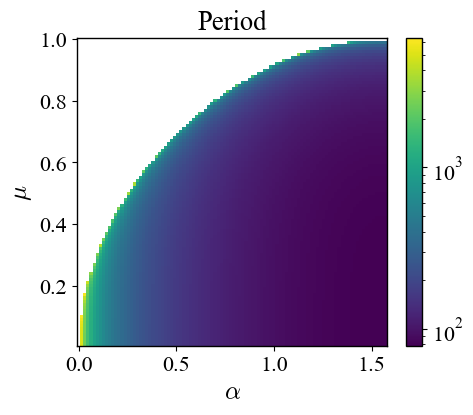

In [103]:
P_max = np.nanmax(P_array)
P_min = np.nanmin(P_array)
plt.figure(figsize=(5,4))
plt.pcolormesh(alphas,betas,P_array,norm=LogNorm(vmin=P_min,vmax=P_max))
plt.colorbar()
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\mu$')
plt.title(r'Period')
plt.show()

In [ ]:
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]
Q1 = 1
shift =1
eta1 = 0.4
Q2 = 0.6
eta2 = 0.5

for beta in tqdm(betas[20:]):

    @parfor(alphas,args=(beta,),bar=False)
    def ParFOR(alpha,beta):
        Z1as,Z1bs,Z2as,Z2bs,t = get_RQ_MOA4(1,Q_init,alpha=alpha,beta=beta,eta1=eta1,eta2=eta2,shift=shift,t_end=t_end,dt=0.1)
        R1 = np.abs(Z1as)[::100]
        R2 = np.abs(Z1bs)[::100]
        Q1 = np.abs(Z2as)[::100]
        Q2 = np.abs(Z2bs)[::100]
        
        return R1,R2,Q1,Q2
    R1,R2,Q1,Q2 = zip(*ParFOR)

    np.savez(f'SIMUL OA/beta = {beta} N = {N}',Q1=Q1,Q2=Q2,R1=R1,R2=R2)